# Please open JupyterLab in the PlanetVis folder itself, otherwise you will get errors below

In [142]:
import spiceypy as spice
spice.kclear() #clearing old kernels from memory

In [143]:
print(spice.tkvrsn('TOOLKIT'))

CSPICE_N0067


# References:

Name              Lesson steps/functions it describes
----------------  -----------------------------------------------
Time              Time Conversion
SCLK and LSK      Time Conversion
SPK               Obtaining Ephemeris Data
Frames            Reference Frames
Using Frames      Reference Frames
PCK               Planetary Constants Data
CK                Spacecraft Orientation Data
DSK               Detailed Target Shape (Topography) Data

In [144]:
import os 
from datetime import datetime
import numpy as np

In [145]:
#furnsh is the function from the spiceypy library to load a kernel

spice.furnsh("kernels/naif0012.tls.txt")

In [146]:
et = spice.str2et("2026-06-01")
print(et)

833544069.1849113


In [147]:
#this is a Mars-related kernel

spice.furnsh("kernels/de440.bsp")

Note: J2000 is set a reference point in time, where it refers to the first moment of January 1, 2000

In [148]:
#spkpos() computes position of a target body relative to observational body

pos, lt = spice.spkpos(
    "MARS BARYCENTER",
    et,
    "J2000",
    "NONE",
    "EARTH BARYCENTER"
)

distance = np.linalg.norm(pos)

print(distance)

326744855.81554955


NOTE: pos is an array with 3 values to represent the 3 dimensions it operates under. lt (light time) is a singular scalar numerical value.

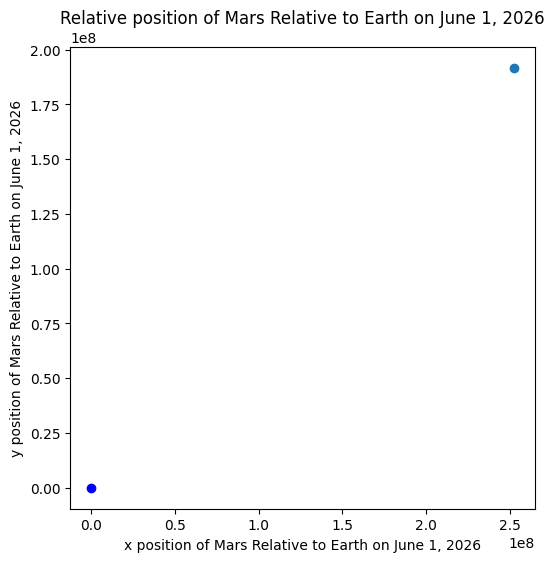

In [149]:
import matplotlib.pyplot as plt

x = pos[0] #x position coordinates of Mars relative to Earth
y = pos[1] #y position coordinates of Mars relative to Earth

plt.figure(figsize=(6,6))
plt.scatter(x,y, label="Mars's Path")
plt.scatter(0, 0, color='blue', label="Earth (Center)")
plt.xlabel("x position of Mars Relative to Earth on June 1, 2026")
plt.ylabel("y position of Mars Relative to Earth on June 1, 2026")
plt.title("Relative position of Mars Relative to Earth on June 1, 2026")
plt.show()

# If we want to make this graph continuous, we need to make a loop to track the positions now

In [150]:
et1 = spice.str2et("2026-01-01") #starting time is the first day of 2026
et2 = spice.str2et("2026-12-31") #ending time is last day of 2026
time_steps = np.linspace(et1, et2, 1000) #1000 data points in between these 6 months

In [151]:
x_pos = []
y_pos = []

for et1 in time_steps:
    pos, lt = spice.spkpos(
    "MARS BARYCENTER",
    et1,
    "J2000",
    "NONE",
    "EARTH BARYCENTER"
    )
    x_pos.append(pos[0])
    y_pos.append(pos[1])

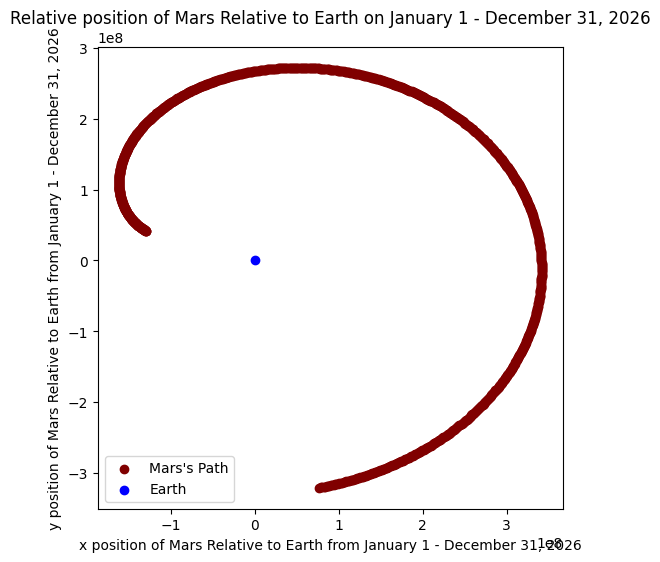

In [152]:
plt.figure(figsize=(6,6))
plt.scatter(x_pos,y_pos, label="Mars's Path", color = "maroon")
plt.scatter(0, 0, color='blue', label="Earth")
plt.xlabel("x position of Mars Relative to Earth from January 1 - December 31, 2026")
plt.ylabel("y position of Mars Relative to Earth from January 1 - December 31, 2026")
plt.title("Relative position of Mars Relative to Earth on January 1 - December 31, 2026")
plt.legend()
plt.show()

# Plotting time vs distance

In [153]:
dates = pd.date_range(
    "2026-01-01",
    "2026-12-31",
    freq="D"
)

In [154]:
distances = []
for i in dates:
    et = spice.str2et(str(i))

    pos, lt = spice.spkpos(
        "MARS BARYCENTER",
        et,
        "J2000",
        "NONE",
        "EARTH BARYCENTER"
    )
    distances.append(np.linalg.norm(pos))

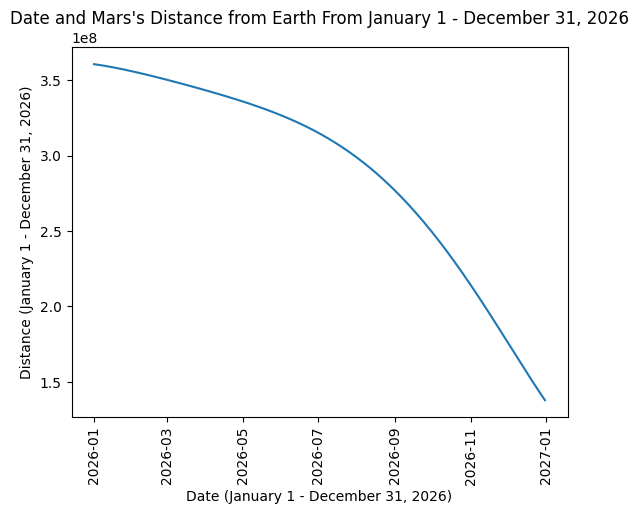

In [155]:
plt.plot(dates, distances)
plt.xticks(rotation=90)
plt.title("Date and Mars's Distance from Earth From January 1 - December 31, 2026")
plt.xlabel("Date (January 1 - December 31, 2026)")
plt.ylabel("Distance (January 1 - December 31, 2026)")
plt.show()

# Generally, the closer Mars is to Earth, the easier it is to observe. So, how do we find the date when the distance between Mars and Earth is the shortest in this time frame?

In [156]:
dates_df = pd.DataFrame({'Date': dates, 'Distance': distances})
dates_df.head()

,Date,Distance
0,2026-01-01,3.606360e+08
1,2026-01-02,3.605177e+08
2,2026-01-03,3.603965e+08
3,2026-01-04,3.602726e+08
4,2026-01-05,3.601459e+08


Alright, we've found the shortest distance between Earth and Mars in this given time. Question is... on what day does this occur?

In [157]:
dates_df.iloc[dates_df["Distance"].idxmin()]

Date        2026-12-31 00:00:00
Distance       137897794.787208
Name: 364, dtype: object

Look at that! Given our time frame, December 31st, 2026 is the best observation day for us in terms of optimal distance.

# But will it be well illuminated enough? Let's find out when the best day is illumination-wise 

This introduces the concept of high vs low phase angle. In our case, we are observing Mars *from* Earth, while having our light come from the sun. 

S = Sun

E = Earth

M = Mars

Lets create a triangle between the three. The phase angle refers to to the angle M, where our observed planet lies. Angle M of ∆EMS

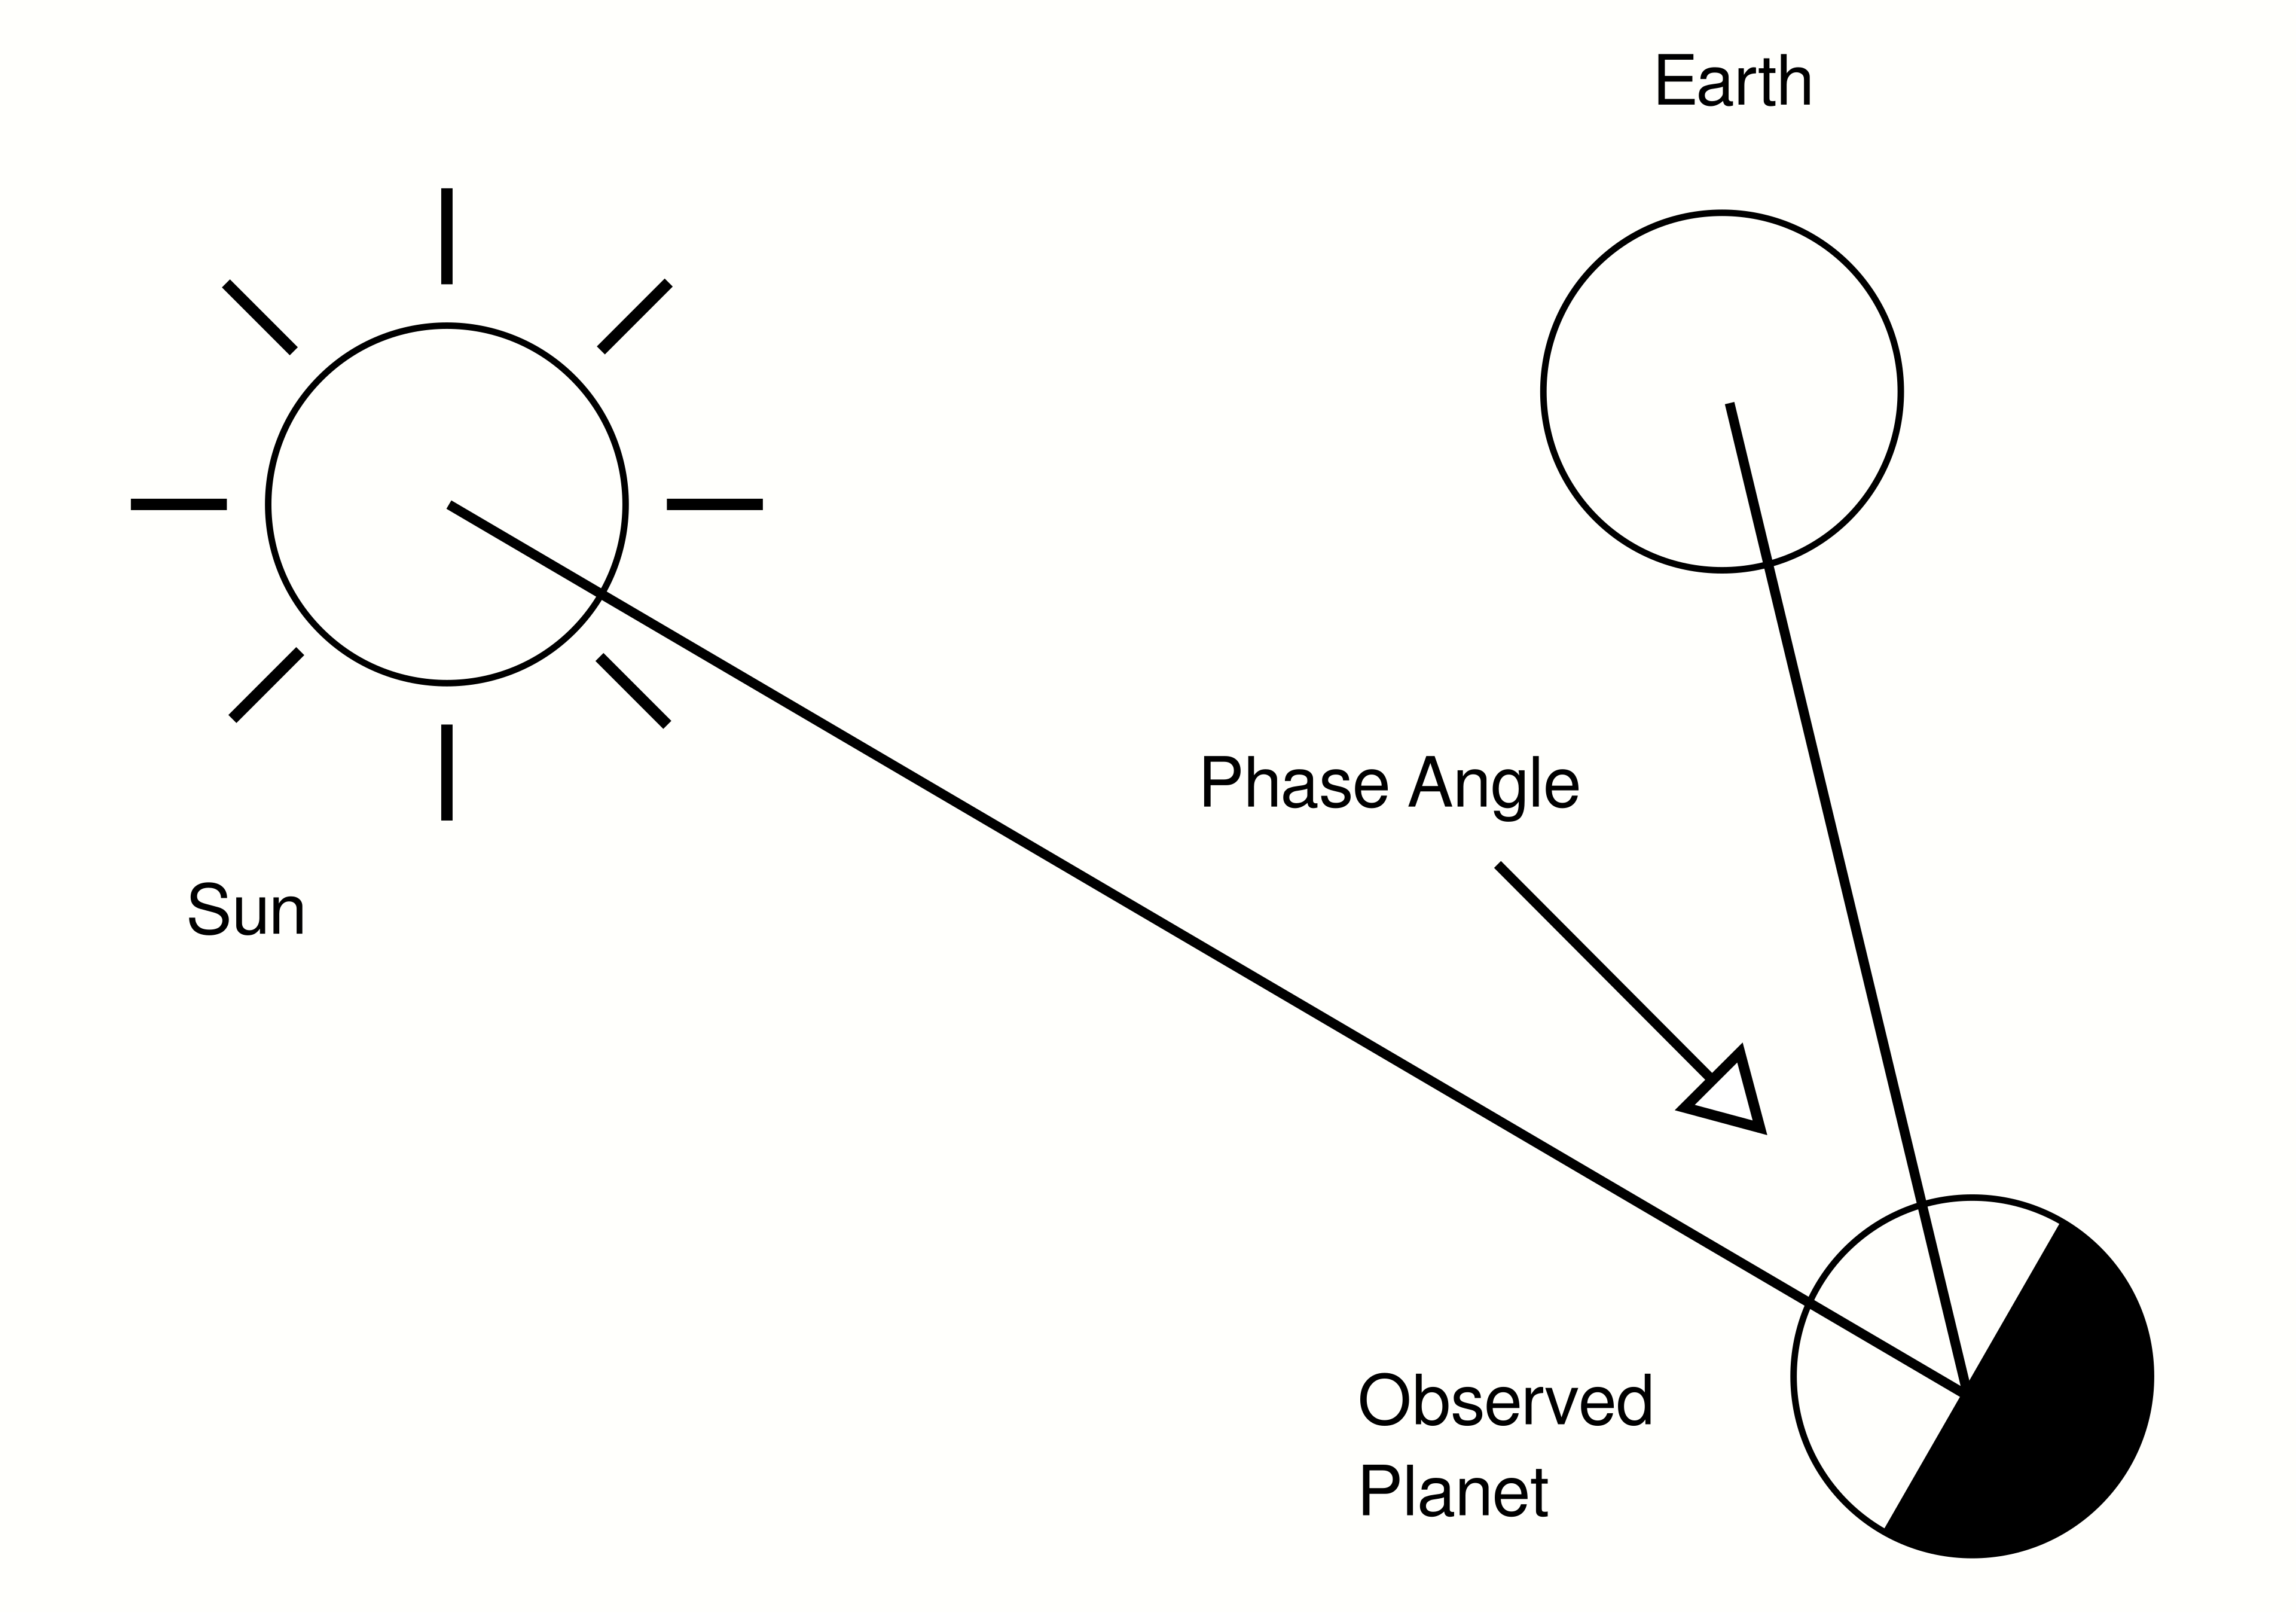

A *low* phase angle is optimal for us. This is because this is when shadows are lowest, so it is easiest to observe our desired planet. 

In [158]:
#function phaseq() is generally used to find the phase angle

phase_angles = []
for i in dates: #using same dates as earlier, entirity of 2026
    et = spice.str2et(str(i))

    phase_angles.append(spice.phaseq(
        et=et,           # Ephemeris time
        target="MARS BARYCENTER",   # Body 1
        illmn="SUN",      # Illuminator/Body 2
        obsrvr="EARTH BARYCENTER",    # Observer
        abcorr="LT+S"     # Aberration correction (e.g., Light Time + Stellar)
    ))

In [159]:
dates_df["Phase angle (Radians)"] = phase_angles
dates_df.head()

,Date,Distance,Phase angle (Radians)
0,2026-01-01,3.606360e+08,0.027635
1,2026-01-02,3.605177e+08,0.024919
2,2026-01-03,3.603965e+08,0.022282
3,2026-01-04,3.602726e+08,0.019755
4,2026-01-05,3.601459e+08,0.017385


Context for evaluating phase angles:



0 radians --> fully illuminated

π/2 radians --> half lit

π radians --> fully dark

In [160]:
import math

dates_df["Phase angle (Degrees)"] = [math.degrees(r) for r in dates_df["Phase angle (Radians)"]]
dates_df.head()

,Date,Distance,Phase angle (Radians),Phase angle (Degrees)
0,2026-01-01,3.606360e+08,0.027635,1.583386
1,2026-01-02,3.605177e+08,0.024919,1.427738
2,2026-01-03,3.603965e+08,0.022282,1.276655
3,2026-01-04,3.602726e+08,0.019755,1.131878
4,2026-01-05,3.601459e+08,0.017385,0.996064


In [161]:
#Renaming df for easier convention

myDF = dates_df

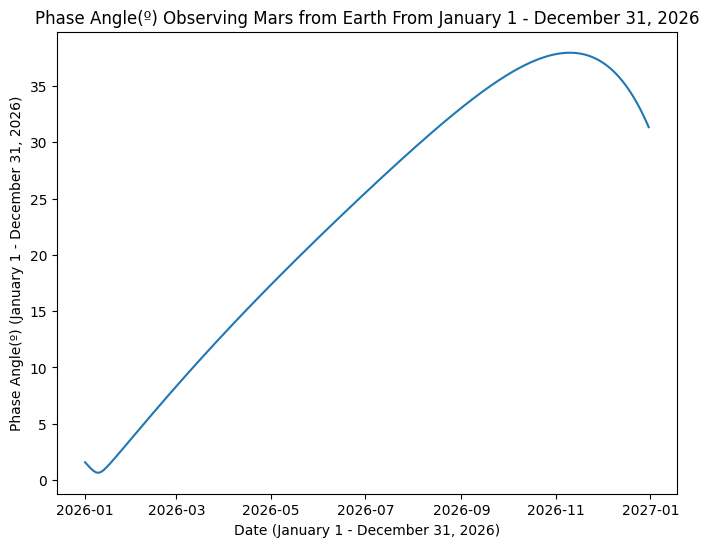

In [162]:
plt.figure(figsize=(8,6))
plt.plot(myDF["Date"], myDF["Phase angle (Degrees)"])
plt.title("Phase Angle(º) Observing Mars from Earth From January 1 - December 31, 2026")
plt.xlabel("Date (January 1 - December 31, 2026)")
plt.ylabel("Phase Angle(º) (January 1 - December 31, 2026)")
plt.show()

Clearly the best time to observe Mars in terms of illumination is extremely early in the year. The single best day, based on the lowest phase angle? Let's calculate that right now.

In [163]:
myDF.iloc[myDF["Phase angle (Degrees)"].idxmin()]

Date                     2026-01-09 00:00:00
Distance                    359612600.142455
Phase angle (Radians)               0.011431
Phase angle (Degrees)               0.654921
Name: 8, dtype: object

In [164]:
#this is NOT what we're looking for, this is just here for brevity and comparison

myDF.iloc[myDF["Phase angle (Degrees)"].idxmax()]

Date                     2026-11-10 00:00:00
Distance                    203187915.240006
Phase angle (Radians)               0.662226
Phase angle (Degrees)              37.942746
Name: 313, dtype: object

Look at that! The phase angle doesnt ever come down to a perfect 0º, but it gets pretty close to that. And this happens exactly on January 9th of 2026. So for the best illumination, we would try to observe Mars on January 9th.

# But there's one more caveat. Solar Elongation. We want to make sure that Mars will not be right in front of the sun, for example, because that would make its observation incredibly difficult

The definition of solar elongation is similar to phase angle. However, instead of the angle being at the body observed, the angle is at the body of the observer.

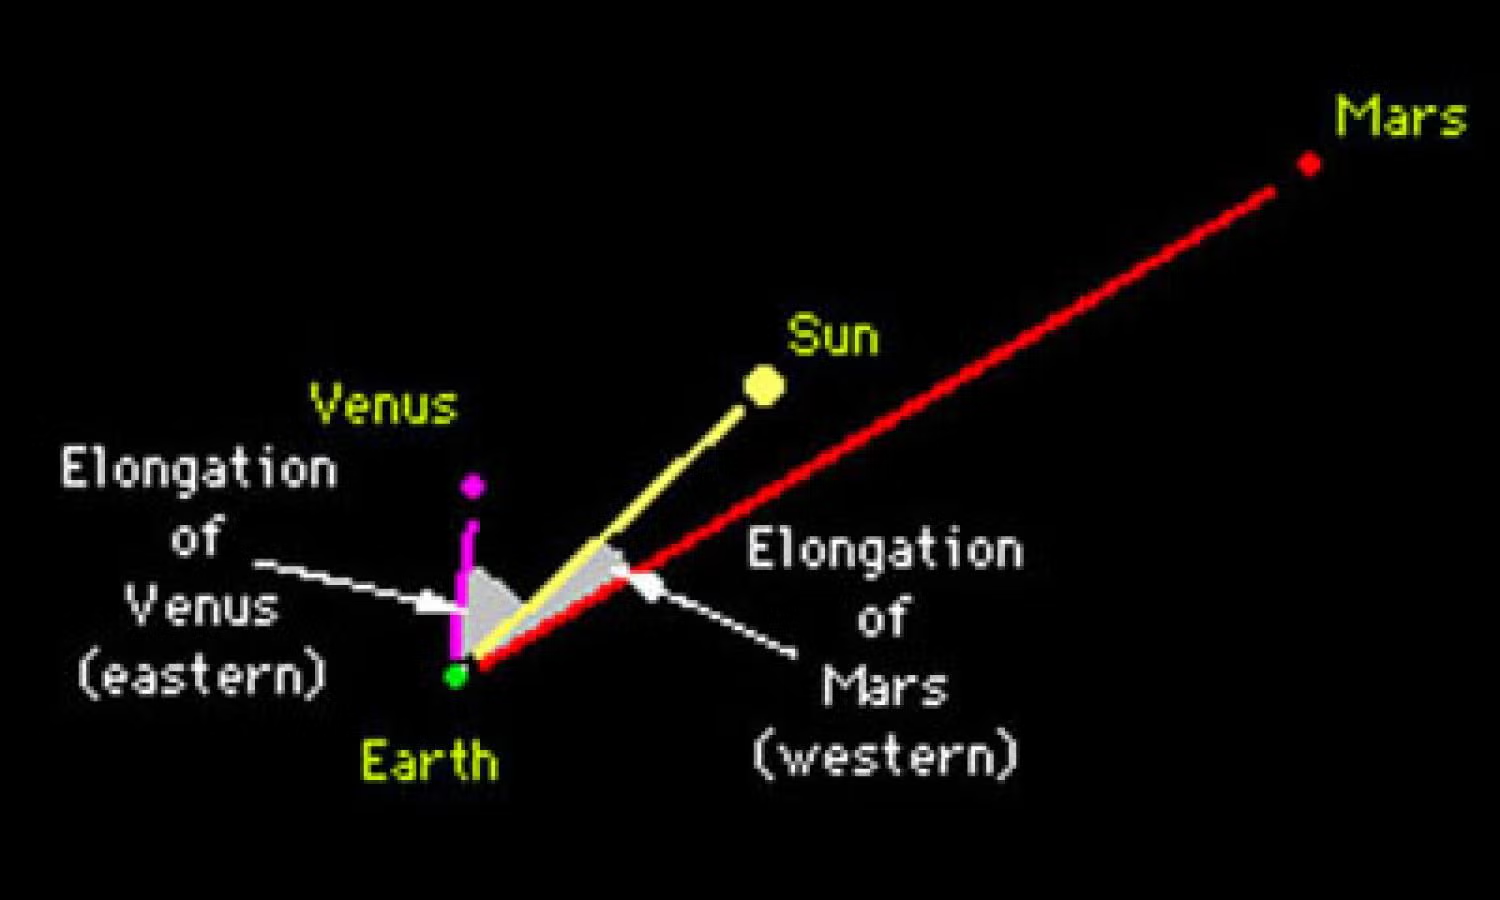

When it comes to what gives us the most observation power, we want our solar elongation angle to be closest to 180º. However, as we will see, we will not have a number close to 180º in our data for the year of 2026. And that's fine! Overall though, you definitely want it to be as close as possible to 180º though.

In [165]:
#vsep() is the python function that gives one the solar elongation angle

solar_elong = []
mars2earth_pos = []
sun2earth_pos = []
j = 0

for i in dates: #using same dates as earlier, entirity of 2026
    et = spice.str2et(str(i))

    mars2earth_pos.append(spice.spkpos(
    "MARS BARYCENTER",
    et,
    "J2000",
    "NONE",
    "EARTH BARYCENTER")[0])

    sun2earth_pos.append(spice.spkpos(
    "SUN",
    et,
    "J2000",
    "NONE",
    "EARTH BARYCENTER")[0])

    solar_elong.append(spice.vsep(sun2earth_pos[j], mars2earth_pos[j]))
    j = j + 1

In [166]:
myDF["Solar Elongation (Radians)"] = solar_elong
myDF.head()

,Date,Distance,Phase angle (Radians),Phase angle (Degrees),Solar Elongation (Radians)
0,2026-01-01,3.606360e+08,0.027635,1.583386,0.040216
1,2026-01-02,3.605177e+08,0.024919,1.427738,0.036241
2,2026-01-03,3.603965e+08,0.022282,1.276655,0.032387
3,2026-01-04,3.602726e+08,0.019755,1.131878,0.028698
4,2026-01-05,3.601459e+08,0.017385,0.996064,0.025239


In [167]:
myDF["Solar Elongation (Degrees)"] = [math.degrees(r) for r in myDF["Solar Elongation (Radians)"]]
myDF.head()

,Date,Distance,Phase angle (Radians),Phase angle (Degrees),Solar Elongation (Radians),Solar Elongation (Degrees)
0,2026-01-01,3.606360e+08,0.027635,1.583386,0.040216,2.304228
1,2026-01-02,3.605177e+08,0.024919,1.427738,0.036241,2.076471
2,2026-01-03,3.603965e+08,0.022282,1.276655,0.032387,1.855651
3,2026-01-04,3.602726e+08,0.019755,1.131878,0.028698,1.644261
4,2026-01-05,3.601459e+08,0.017385,0.996064,0.025239,1.446103


In [168]:
#compiling everything into a set, different CSV

myDF.to_csv('sun_mars_earth_geometry.csv')

In [170]:
#finding the closest solar elongation to 180º

myDF["Solar Elongation (Degrees)"][np.abs(np.array(myDF["Solar Elongation (Degrees)"]) - 180).argmin()]

np.float64(119.50608569794312)

In [172]:
#finding the closest solar elongation DATE to 180º

myDF.iloc[np.abs(np.array(myDF["Solar Elongation (Degrees)"]) - 180).argmin()]

Date                          2026-12-31 00:00:00
Distance                         137897794.787208
Phase angle (Radians)                    0.546854
Phase angle (Degrees)                    31.33241
Solar Elongation (Radians)               2.085775
Solar Elongation (Degrees)             119.506086
Name: 364, dtype: object

So the best day to observe anglewise, preventing the sun from obscuring our view is December 31st, the very last day of the year.

Overall, this leaves us with a pretty big dillema. Distancewise and anglewise, December 31st is the best day to observe Mars, but we have rather poor illumination during that time. While the best time of 2026 to observe Mars from Earth is open to interpretation, I would choose December 31st, 2026 as the best day overall. This is because, while the illumination isn't great, our sun-mars-earth system is recovering from a maximum phase angle and there is no other time during the rest of the year where the distance and angle are as optimal.

# In conclusion, December 31st, 2026, is the best day to observe Mars from Earth. That's one way to celebrate the end of the year!